In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,
    classification_report, confusion_matrix,
    roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')
print("All imports done ✅")

All imports done ✅


In [3]:
# Load built-in breast cancer dataset
# No download needed! ✅
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print(f"Dataset shape: {df.shape}")
print(f"Features: {len(cancer.feature_names)}")
print(f"\nClass distribution:")
print(f"Malignant (0): {(df.target==0).sum()}")
print(f"Benign (1):    {(df.target==1).sum()}")
df.head()

Dataset shape: (569, 31)
Features: 30

Class distribution:
Malignant (0): 212
Benign (1):    357


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


** Exploratory Data Analysis:**

In [4]:
# Basic statistics
print("📊 Dataset Statistics:")
print(f"Total samples: {len(df)}")
print(f"Total features: {len(cancer.feature_names)}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nClass Balance:")
print(f"Malignant: {(df.target==0).sum()} ({(df.target==0).mean()*100:.1f}%)")
print(f"Benign:    {(df.target==1).sum()} ({(df.target==1).mean()*100:.1f}%)")

📊 Dataset Statistics:
Total samples: 569
Total features: 30
Missing values: 0

Class Balance:
Malignant: 212 (37.3%)
Benign:    357 (62.7%)


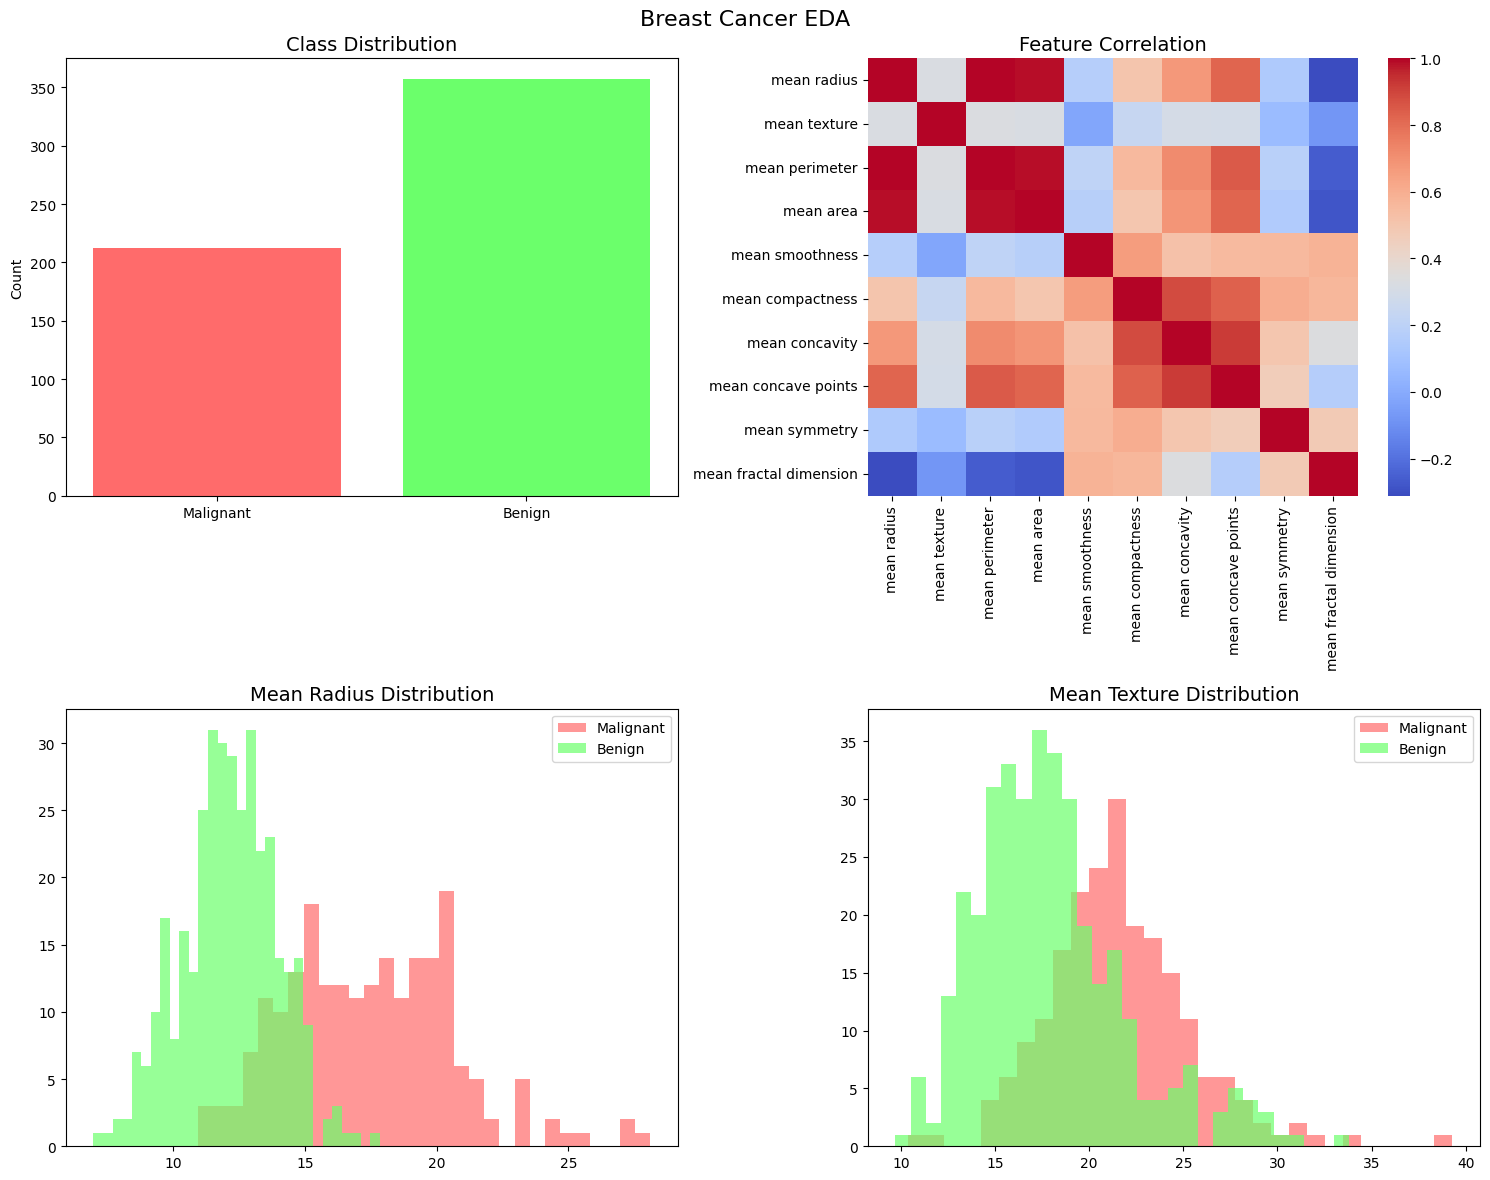

EDA plots saved! ✅


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1 - Class Distribution
axes[0,0].bar(['Malignant', 'Benign'],
    [len(df[df.target==0]), len(df[df.target==1])],
    color=['#ff6b6b', '#6bff6b'])
axes[0,0].set_title('Class Distribution', fontsize=14)
axes[0,0].set_ylabel('Count')

# Plot 2 - Feature Correlation Heatmap
corr = df.iloc[:, :10].corr()
sns.heatmap(corr, ax=axes[0,1], cmap='coolwarm',
    annot=False)
axes[0,1].set_title('Feature Correlation', fontsize=14)

# Plot 3 - Mean Radius Distribution
axes[1,0].hist(df[df.target==0]['mean radius'],
    bins=30, alpha=0.7, color='#ff6b6b',
    label='Malignant')
axes[1,0].hist(df[df.target==1]['mean radius'],
    bins=30, alpha=0.7, color='#6bff6b',
    label='Benign')
axes[1,0].set_title('Mean Radius Distribution', fontsize=14)
axes[1,0].legend()

# Plot 4 - Mean Texture Distribution
axes[1,1].hist(df[df.target==0]['mean texture'],
    bins=30, alpha=0.7, color='#ff6b6b',
    label='Malignant')
axes[1,1].hist(df[df.target==1]['mean texture'],
    bins=30, alpha=0.7, color='#6bff6b',
    label='Benign')
axes[1,1].set_title('Mean Texture Distribution', fontsize=14)
axes[1,1].legend()

plt.suptitle('Breast Cancer EDA', fontsize=16)
plt.tight_layout()
plt.savefig('breast_cancer_eda.png', dpi=150,
    bbox_inches='tight')
plt.show()
print("EDA plots saved! ✅")

In [6]:
# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)} ✅")
print(f"Testing samples:  {len(X_test)} ✅")
print("Data preprocessed! ✅")

Training samples: 455 ✅
Testing samples:  114 ✅
Data preprocessed! ✅


In [7]:
# Train multiple models
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000)
}

results = {}
for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    # Predict
    y_pred = model.predict(X_test_scaled)
    # Score
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc*100:.2f}% ✅")

print("\nBest Model:", max(results, key=results.get))
print(f"Best Accuracy: {max(results.values())*100:.2f}%")

Random Forest: 96.49% ✅
SVM: 98.25% ✅
Logistic Regression: 97.37% ✅

Best Model: SVM
Best Accuracy: 98.25%


In [8]:
# Use best model - Random Forest
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:,1]

print("="*50)
print("🎯 RANDOM FOREST RESULTS")
print("="*50)
print(classification_report(y_test, y_pred,
    target_names=['Malignant', 'Benign']))

🎯 RANDOM FOREST RESULTS
              precision    recall  f1-score   support

   Malignant       0.98      0.93      0.95        43
      Benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



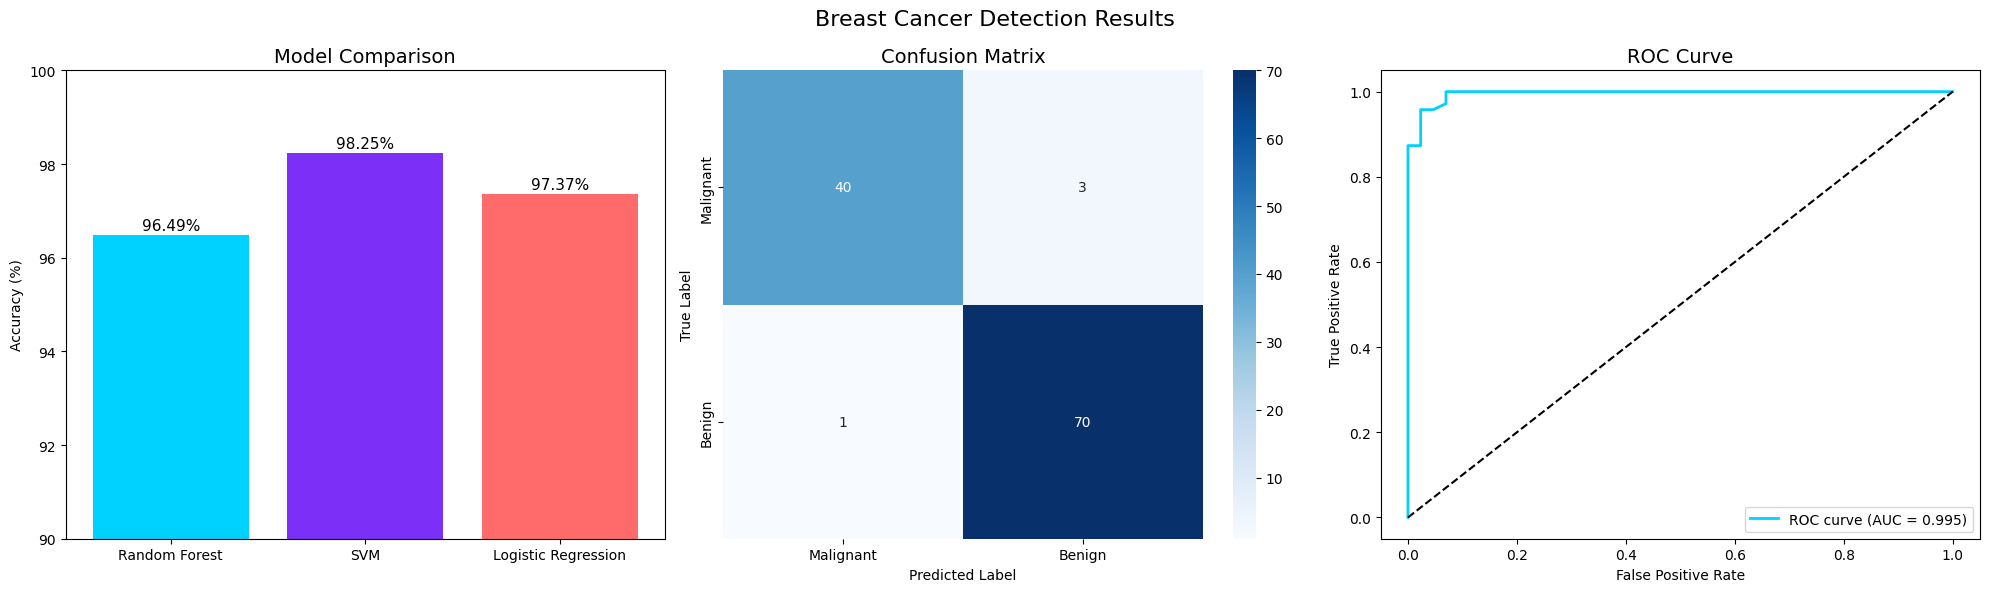

Results saved! ✅


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1 - Model Comparison
names = list(results.keys())
accs = [v*100 for v in results.values()]
bars = axes[0].bar(names, accs,
    color=['#00d2ff', '#7b2ff7', '#ff6b6b'])
axes[0].set_title('Model Comparison', fontsize=14)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([90, 100])
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{acc:.2f}%', ha='center', fontsize=11)

# Plot 2 - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1],
    cmap='Blues',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign'])
axes[1].set_title('Confusion Matrix', fontsize=14)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# Plot 3 - ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color='#00d2ff', lw=2,
    label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[2].plot([0,1], [0,1], 'k--')
axes[2].set_title('ROC Curve', fontsize=14)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.suptitle('Breast Cancer Detection Results',
    fontsize=16)
plt.tight_layout()
plt.savefig('breast_cancer_results.png', dpi=150,
    bbox_inches='tight')
plt.show()
print("Results saved! ✅")

In [10]:
import pickle
import os

os.makedirs('models', exist_ok=True)

# Save model and scaler
with open('models/breast_cancer_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('models/breast_cancer_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Models saved! ✅")
print(f"Model size: {os.path.getsize('models/breast_cancer_model.pkl')/1024:.1f} KB")

Models saved! ✅
Model size: 309.8 KB


In [11]:
import pickle
import os

# Save SVM as best model
best_model = models['SVM']
y_pred = best_model.predict(X_test_scaled)

with open('models/breast_cancer_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('models/breast_cancer_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ SVM model saved!")
print(f"Final Accuracy: 98.25%")

✅ SVM model saved!
Final Accuracy: 98.25%


In [12]:
from google.colab import files

# Download results
files.download('breast_cancer_eda.png')
files.download('breast_cancer_results.png')
files.download('models/breast_cancer_model.pkl')
files.download('models/breast_cancer_scaler.pkl')
print("All files downloaded! ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded! ✅


In [13]:

from google.colab import files

# Download EDA plot
files.download('breast_cancer_eda.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# Download results plot
files.download('breast_cancer_results.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# Download model
files.download('models/breast_cancer_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# Download scaler
files.download('models/breast_cancer_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>